If you use colab. Add the files used into the file or directory the notebook is being run out of. If you would like to run this from you own device. Just comment this out this cell.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Import packages

In [ ]:
import logging
import time
from typing import Union, Dict, Any

import math
import statistics

import pandas as pd
import numpy as np
import networkx as nx
from scipy import sparse
import matplotlib.pyplot as plt

from itertools import combinations

from networkx.algorithms.community import asyn_lpa_communities


from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    cohen_kappa_score,
    balanced_accuracy_score,
    precision_recall_curve,
    roc_curve,
    ndcg_score
)
from sklearn.calibration import calibration_curve


Variable Declaration and path definitions.

In [ ]:
# ---- CONFIG ----
#Remember to remove my path
FILE1 = "/content/drive/MyDrive/COMP 6130/CA-GrQc.txt" # path to your file
FILE2 = "/content/drive/MyDrive/COMP 6130/com-dblp.ungraph.txt" # path to your file2
DIRECTED1 = True             # True ➜ directed
DIRECTED2 = False             # False ➜ undirected
COMMENT = "#"               # lines starting with this are ignored

Configure logger for File Not Found exceptions.

In [ ]:
def _configure_logger() -> logging.Logger:
    """
    Configure and return a module-level logger with INFO level and streamlined output.
    Prevents duplicate messages by disabling propagation to the root logger.
    """
    # Get a logger named after this module
    logger = logging.getLogger(__name__)

    # Only add handlers if the logger has none yet (avoids duplicate handlers)
    if not logger.handlers:
        # StreamHandler outputs to stderr by default
        handler = logging.StreamHandler()
        # Formatter outputs only level and message, omitting module name
        formatter = logging.Formatter('%(levelname)s: %(message)s')
        handler.setFormatter(formatter)
        logger.addHandler(handler)

    # Set the logging level to INFO
    logger.setLevel(logging.INFO)
    # Prevent this logger from passing messages to ancestor handlers
    logger.propagate = False
    return logger

# Instantiate the configured logger
logger = _configure_logger()

In [ ]:
def load_graph(
    path: str,
    directed: bool = True,
    comment: str = "#"
) -> Union[nx.Graph, nx.DiGraph]:
    """
    Load an edge list from a file into a NetworkX graph, counting repeated edges as weights.

    Args:
        path: Path to the edge list file.
        directed: Whether to create a directed graph.
        comment: Character indicating comment lines to skip.

    Returns:
        A NetworkX Graph or DiGraph with weighted edges.
    """
    # Choose graph class based on directed flag
    GraphType = nx.DiGraph if directed else nx.Graph
    G = GraphType()

    # Start timing for performance measurement
    start_time = time.perf_counter()
    try:
        with open(path, 'r') as f:
            for lineno, raw_line in enumerate(f, start=1):
                line = raw_line.strip()

                # Skip blank lines or those starting with the comment character
                if not line or line.startswith(comment):
                    continue

                parts = line.split()
                # Warn and skip if line doesn't have exactly two nodes
                if len(parts) != 2:
                    logger.warning(
                        "Skipping malformed line %d: '%s'", lineno, raw_line.strip()
                    )
                    continue

                src, dst = parts
                # Increment weight if edge exists, otherwise add new edge with weight=1
                if G.has_edge(src, dst):
                    G[src][dst]["weight"] += 1
                else:
                    G.add_edge(src, dst, weight=1)
    except FileNotFoundError:
        # Specific error if file path is invalid
        logger.error("File not found: %s", path)
        raise
    except PermissionError:
        # Specific error if lacking permissions
        logger.error("Permission denied: %s", path)
        raise
    except Exception:
        # Catch-all for unexpected issues during file I/O or parsing
        logger.exception("Unexpected error while loading graph from %s", path)
        raise
    finally:
        # Stop timing regardless of success or failure
        end_time = time.perf_counter()
        duration = end_time - start_time

    # Log summary of the loaded graph
    logger.info(
        "Loaded graph in %.2f seconds with %d nodes and %d edges",
        duration,
        G.number_of_nodes(),
        G.number_of_edges()
    )

    return G

# Load two graphs and print their sizes
G1 = load_graph(FILE1, directed=DIRECTED1, comment=COMMENT)
G2 = load_graph(FILE2, directed=DIRECTED2, comment=COMMENT)

INFO: Loaded graph in 2.01 seconds with 5242 nodes and 28980 edges
INFO: Loaded graph in 4.72 seconds with 317080 nodes and 1049866 edges


Metrics

Nodes: 5,242  Edges: 28,980  Total weight: 28,980

Weights – Min: 1, Q1: 1, Med: 1, Q3: 1, Max: 1

Avg In: 5.53, Avg Out: 5.53
Avg W-In: 5.53, Avg W-Out: 5.53

Top nodes by degree:
 Node  Out-Degree
21012          81
21281          79
22691          77
12365          77
 6610          68
 9785          68
21508          67
17655          66
 2741          65
19423          63 

Top nodes by weighted degree:
 Node  W-Out-Degree
21012            81
21281            79
22691            77
12365            77
 6610            68
 9785            68
21508            67
17655            66
 2741            65
19423            63 

Components: 355, Largest: 4158 nodes (79.3%)

Avg clustering: 0.530

Top nodes by PageRank:
 Node  PageRank
14265  0.001449
13801  0.001342
13929  0.001305
 9572  0.001173
 2710  0.001153
21281  0.001153
 7689  0.001096
22691  0.001082
 6264  0.001071
21012  0.001069 

--- In-Degree Distribution data ---
 bin_left  bin_right  count
      1.0        5.0   3585
     

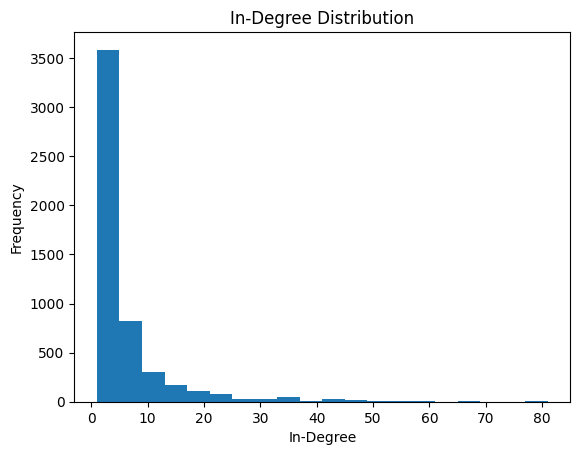

--- Out-Degree Distribution data ---
 bin_left  bin_right  count
      1.0        5.0   3585
      5.0        9.0    821
      9.0       13.0    303
     13.0       17.0    168
     17.0       21.0    110
     21.0       25.0     80
     25.0       29.0     23
     29.0       33.0     23
     33.0       37.0     49
     37.0       41.0      7
     41.0       45.0     25
     45.0       49.0     22
     49.0       53.0      6
     53.0       57.0      6
     57.0       61.0      3
     61.0       65.0      2
     65.0       69.0      5
     69.0       73.0      0
     73.0       77.0      0
     77.0       81.0      4 



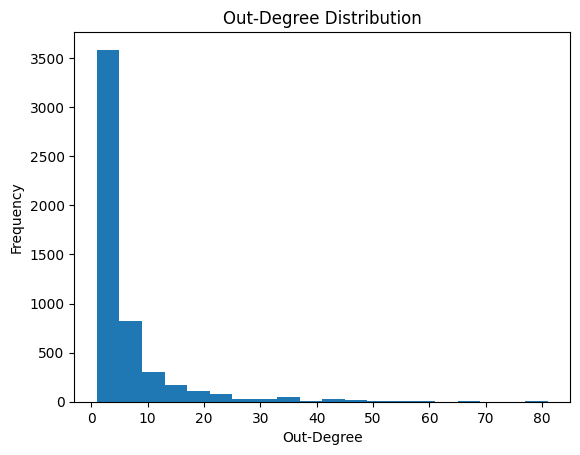

--- Weighted In-Degree data ---
 bin_left  bin_right  count
      1.0        5.0   3585
      5.0        9.0    821
      9.0       13.0    303
     13.0       17.0    168
     17.0       21.0    110
     21.0       25.0     80
     25.0       29.0     23
     29.0       33.0     23
     33.0       37.0     49
     37.0       41.0      7
     41.0       45.0     25
     45.0       49.0     22
     49.0       53.0      6
     53.0       57.0      6
     57.0       61.0      3
     61.0       65.0      2
     65.0       69.0      5
     69.0       73.0      0
     73.0       77.0      0
     77.0       81.0      4 



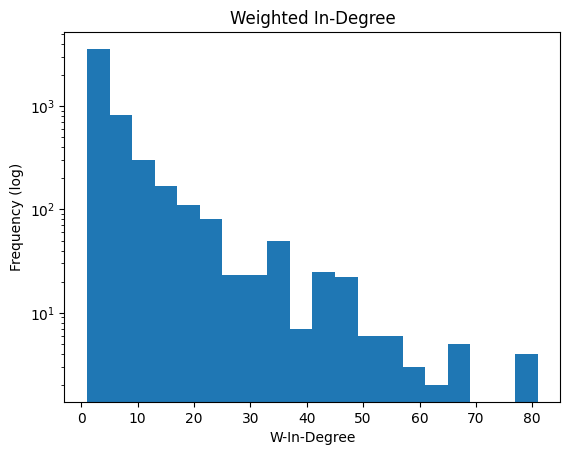

--- Weighted Out-Degree data ---
 bin_left  bin_right  count
      1.0        5.0   3585
      5.0        9.0    821
      9.0       13.0    303
     13.0       17.0    168
     17.0       21.0    110
     21.0       25.0     80
     25.0       29.0     23
     29.0       33.0     23
     33.0       37.0     49
     37.0       41.0      7
     41.0       45.0     25
     45.0       49.0     22
     49.0       53.0      6
     53.0       57.0      6
     57.0       61.0      3
     61.0       65.0      2
     65.0       69.0      5
     69.0       73.0      0
     73.0       77.0      0
     77.0       81.0      4 



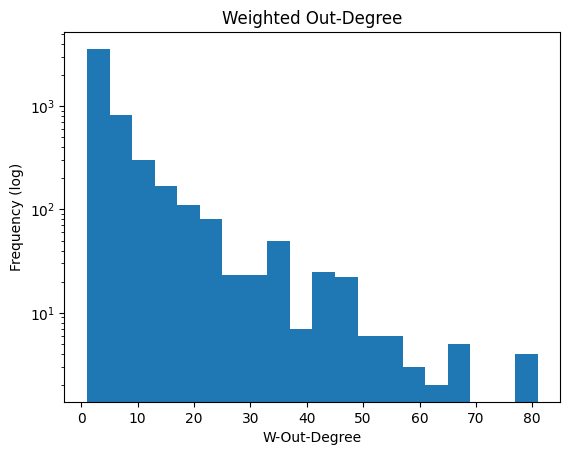

--- Component Size Distribution data ---
 bin_left  bin_right  count
     1.00     208.85    354
   208.85     416.70      0
   416.70     624.55      0
   624.55     832.40      0
   832.40    1040.25      0
  1040.25    1248.10      0
  1248.10    1455.95      0
  1455.95    1663.80      0
  1663.80    1871.65      0
  1871.65    2079.50      0
  2079.50    2287.35      0
  2287.35    2495.20      0
  2495.20    2703.05      0
  2703.05    2910.90      0
  2910.90    3118.75      0
  3118.75    3326.60      0
  3326.60    3534.45      0
  3534.45    3742.30      0
  3742.30    3950.15      0
  3950.15    4158.00      1 



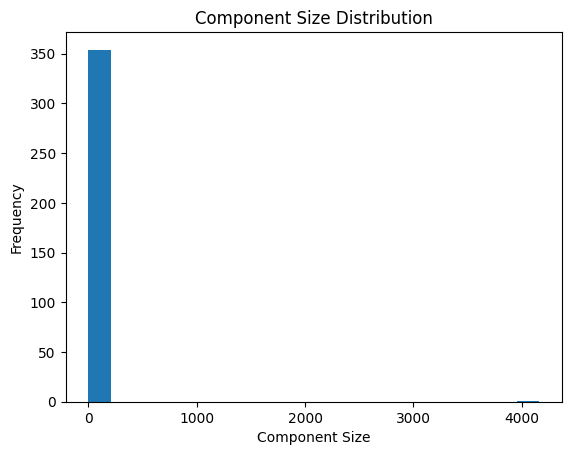

{'n_nodes': 5242,
 'n_edges': 28980,
 'total_weight': np.float64(28980.0),
 'weight_quartiles': (1.0,
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  1.0),
 'avg_in_degree': np.float64(5.528424265547501),
 'avg_out_degree': np.float64(5.528424265547501),
 'avg_w_in_degree': np.float64(5.528424265547501),
 'avg_w_out_degree': np.float64(5.528424265547501),
 'components': 355,
 'largest_cc': 4158,
 'pct_largest': 79.32086989698588,
 'avg_clustering': 0.529635811052136,
 'top_degree': [('21012', 81),
  ('21281', 79),
  ('22691', 77),
  ('12365', 77),
  ('6610', 68),
  ('9785', 68),
  ('21508', 67),
  ('17655', 66),
  ('2741', 65),
  ('19423', 63)],
 'top_wdegree': [('21012', 81),
  ('21281', 79),
  ('22691', 77),
  ('12365', 77),
  ('6610', 68),
  ('9785', 68),
  ('21508', 67),
  ('17655', 66),
  ('2741', 65),
  ('19423', 63)],
 'top_pagerank': [('14265', 0.0014490971768021381),
  ('13801', 0.00134243218429518),
  ('13929', 0.0013051988727175996),
  ('9572', 0.00117269795867048

In [ ]:
def summarize_graph(
    G: Union[nx.Graph, nx.DiGraph],
    top_n: int = 10
) -> Dict[str, Any]:
    """
    Compute, display, and plot metrics for G (directed or undirected).
    Always generates histograms for degree, weighted-degree, and component sizes,
    printing the bin‐counts before each plot.
    """
    if not isinstance(G, (nx.Graph, nx.DiGraph)):
        raise TypeError("G must be a networkx Graph or DiGraph")

    directed = G.is_directed()
    n_nodes = G.number_of_nodes()
    n_edges = G.number_of_edges()

    # Edge weights
    weights = np.fromiter(
        (d.get("weight", 1) for _, _, d in G.edges(data=True)),
        float
    )
    total_w = weights.sum() if weights.size else 0.0

    # Weight quartiles
    if weights.size:
        wmin = float(weights.min())
        q1, med, q3 = np.percentile(weights, [25, 50, 75])
        wmax = float(weights.max())
    else:
        wmin = q1 = med = q3 = wmax = 0.0

    # Degree stats
    if directed:
        in_deg  = np.fromiter(dict(G.in_degree()).values(), int)
        out_deg = np.fromiter(dict(G.out_degree()).values(), int)
        w_in    = np.fromiter((G.in_degree(n, weight="weight") for n in G), float)
        w_out   = np.fromiter((G.out_degree(n, weight="weight") for n in G), float)
        avg_in, avg_out = in_deg.mean(), out_deg.mean()
        avg_w_in, avg_w_out = w_in.mean(), w_out.mean()
    else:
        deg   = np.fromiter(dict(G.degree()).values(), int)
        w_deg = np.fromiter((G.degree(n, weight="weight") for n in G), float)
        avg_deg, avg_w_deg = deg.mean(), w_deg.mean()

    # Connectivity
    if directed:
        comp_count = nx.number_weakly_connected_components(G)
        comp_iter  = nx.weakly_connected_components(G)
    else:
        comp_count = nx.number_connected_components(G)
        comp_iter  = nx.connected_components(G)
    comp_sizes = np.fromiter((len(c) for c in comp_iter), int)
    largest = int(comp_sizes.max()) if comp_sizes.size else 0
    pct = (largest / n_nodes * 100) if n_nodes else 0.0

    # Clustering & PageRank
    und = G.to_undirected() if directed else G
    avg_clust = nx.average_clustering(und, weight="weight")
    pr = nx.pagerank(G, weight="weight")

    # Top-N tables
    if directed:
        top_deg  = sorted(G.out_degree(weight=None),   key=lambda x: x[1], reverse=True)[:top_n]
        top_wdeg = sorted(G.out_degree(weight="weight"), key=lambda x: x[1], reverse=True)[:top_n]
        df_deg   = pd.DataFrame(top_deg,  columns=["Node","Out-Degree"])
        df_wdeg  = pd.DataFrame(top_wdeg, columns=["Node","W-Out-Degree"])
    else:
        top_deg  = sorted(G.degree(weight=None),   key=lambda x: x[1], reverse=True)[:top_n]
        top_wdeg = sorted(G.degree(weight="weight"), key=lambda x: x[1], reverse=True)[:top_n]
        df_deg   = pd.DataFrame(top_deg,  columns=["Node","Degree"])
        df_wdeg  = pd.DataFrame(top_wdeg, columns=["Node","W-Degree"])
    top_pr = sorted(pr.items(), key=lambda x: x[1], reverse=True)[:top_n]
    df_pr  = pd.DataFrame(top_pr, columns=["Node","PageRank"])

    # --- Print metrics ---
    print(f"Nodes: {n_nodes:,}  Edges: {n_edges:,}  Total weight: {total_w:,.0f}\n")
    print(f"Weights – Min: {wmin:.0f}, Q1: {q1:.0f}, Med: {med:.0f}, Q3: {q3:.0f}, Max: {wmax:.0f}\n")

    if directed:
        print(f"Avg In: {avg_in:.2f}, Avg Out: {avg_out:.2f}")
        print(f"Avg W-In: {avg_w_in:.2f}, Avg W-Out: {avg_w_out:.2f}\n")
    else:
        print(f"Avg Deg: {avg_deg:.2f}, Avg W-Deg: {avg_w_deg:.2f}\n")

    print("Top nodes by degree:")
    print(df_deg.to_string(index=False), "\n")
    print("Top nodes by weighted degree:")
    print(df_wdeg.to_string(index=False), "\n")

    print(f"Components: {comp_count}, Largest: {largest} nodes ({pct:.1f}%)\n")
    print(f"Avg clustering: {avg_clust:.3f}\n")
    print("Top nodes by PageRank:")
    print(df_pr.to_string(index=False), "\n")

    # --- Histogram helper with data printout ---
    def _plot_hist(data, title, xlabel, log=False):
        counts, bin_edges = np.histogram(data, bins=20)
        # print the raw histogram data
        hist_df = pd.DataFrame({
            "bin_left":  bin_edges[:-1],
            "bin_right": bin_edges[1:],
            "count":     counts
        })
        print(f"--- {title} data ---")
        print(hist_df.to_string(index=False), "\n")
        # now plot
        plt.figure()
        plt.hist(data, bins=bin_edges, log=log)
        plt.title(title)
        plt.xlabel(xlabel)
        plt.ylabel("Frequency" + (" (log)" if log else ""))
        plt.show()

    # --- Always plot histograms ---
    if directed:
        _plot_hist(in_deg,  "In-Degree Distribution",  "In-Degree")
        _plot_hist(out_deg, "Out-Degree Distribution", "Out-Degree")
        _plot_hist(w_in,    "Weighted In-Degree",      "W-In-Degree", log=True)
        _plot_hist(w_out,   "Weighted Out-Degree",     "W-Out-Degree", log=True)
    else:
        _plot_hist(deg,   "Degree Distribution",         "Degree")
        _plot_hist(w_deg, "Weighted Degree Distribution","W-Degree", log=True)
    _plot_hist(comp_sizes, "Component Size Distribution", "Component Size")

    return {
        "n_nodes": n_nodes,
        "n_edges": n_edges,
        "total_weight": total_w,
        "weight_quartiles": (wmin, q1, med, q3, wmax),
        **( {"avg_in_degree": avg_in, "avg_out_degree": avg_out,
             "avg_w_in_degree": avg_w_in, "avg_w_out_degree": avg_w_out}
           if directed else
           {"avg_degree": avg_deg, "avg_w_degree": avg_w_deg} ),
        "components": comp_count,
        "largest_cc": largest,
        "pct_largest": pct,
        "avg_clustering": avg_clust,
        "top_degree": top_deg,
        "top_wdegree": top_wdeg,
        "top_pagerank": top_pr,
    }


summarize_graph(G1, top_n=10)

Degree Distribution and stats

Min degree: 2
Max degree: 162
Median degree: 6.0
Mean degree: 11.06


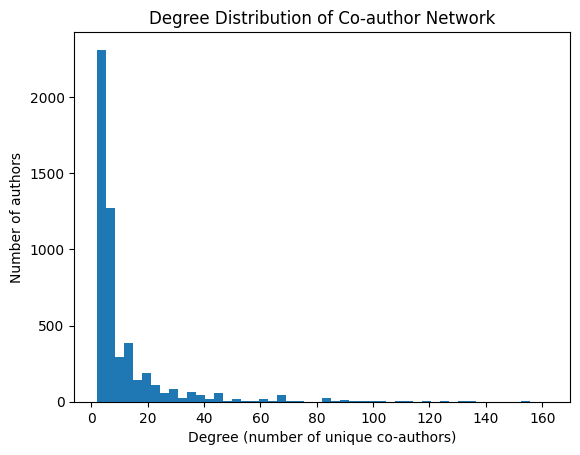

In [ ]:
degrees = [d for _, d in G1.degree()]

# 2. Basic stats
print(f"Min degree: {min(degrees)}")
print(f"Max degree: {max(degrees)}")
print(f"Median degree: {statistics.median(degrees)}")
print(f"Mean degree: {statistics.mean(degrees):.2f}")

# 3. Plot the histogram
plt.figure()
plt.hist(degrees, bins=50)
plt.title("Degree Distribution of Co‐author Network")
plt.xlabel("Degree (number of unique co-authors)")
plt.ylabel("Number of authors")
plt.show()

Component Analysis


In [ ]:
weak_comp_sizes = [len(c) for c in nx.weakly_connected_components(G1)]
print(f"Number of weakly connected components: {len(weak_comp_sizes)}")
print(f"Mean component size: {statistics.mean(weak_comp_sizes):.1f}")
print(f"Largest component size: {max(weak_comp_sizes)}")

Number of weakly connected components: 355
Mean component size: 14.8
Largest component size: 4158


Community Detection

Community 1 — size 184
  Sample authors: ['22691', '12981', '16722', '18910', '14540', '12701', '163', '12365', '731', '25189'] …

Community 2 — size 62
  Sample authors: ['21379', '22975', '7522', '8505', '17289', '4068', '15580', '16389', '13929', '9255'] …

Community 3 — size 51
  Sample authors: ['12968', '88', '15933', '6895', '15010', '2535', '12710', '2338', '12507', '9313'] …

Community 4 — size 41
  Sample authors: ['20000', '11444', '81', '23302', '18940', '18052', '12287', '9023', '21968', '14746'] …

Community 5 — size 40
  Sample authors: ['19527', '1915', '19493', '23149', '12861', '13010', '5953', '15311', '9066', '2630'] …

Number of communities: 1043
Mean size: 5.0, median size: 3
Largest: 184, smallest: 1
Found 1043 communities
  Largest: 184, Smallest: 1, Median: 3


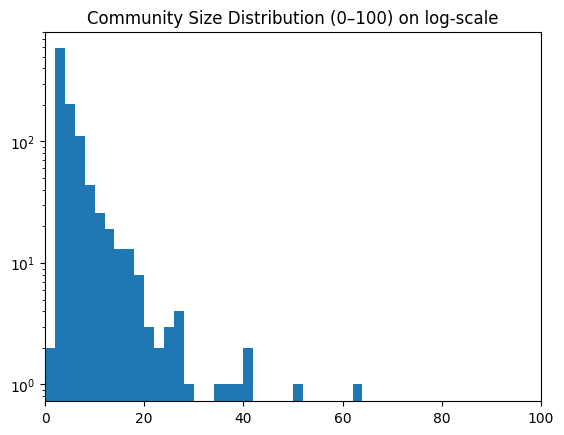

In [ ]:
# Make undirected for community detection
und = G1.to_undirected()

# Run greedy modularity
communities = list(asyn_lpa_communities(und, weight='weight'))

# Sort communities by size
communities = sorted(communities, key=lambda c: len(c), reverse=True)

# Print the top 5 communities
for i, comm in enumerate(communities[:5], start=1):
    print(f"Community {i} — size {len(comm)}")
    print("  Sample authors:", list(comm)[:10], "…\n")


sizes = [len(c) for c in communities]
print(f"Number of communities: {len(sizes)}")
print(f"Mean size: {statistics.mean(sizes):.1f}, median size: {statistics.median(sizes)}")
print(f"Largest: {max(sizes)}, smallest: {min(sizes)}")

# Get the size of each community
sizes = [len(c) for c in communities]

# 4. Print basic stats
print(f"Found {len(sizes)} communities")
print(f"  Largest: {max(sizes)}, Smallest: {min(sizes)}, Median: {sorted(sizes)[len(sizes)//2]}")

plt.figure()
plt.hist(sizes, bins=50, range=(0, 100))
plt.xlim(0, 100)
plt.yscale('log')
plt.title("Community Size Distribution (0–100) on log-scale")
plt.show()


#We'll convert to undirected for neighborhood stats:
und = G1.to_undirected()

# Build a map: node → community ID
community_map = {}
for cid, comm in enumerate(communities):
    for n in comm:
        community_map[n] = cid

# Precompute neighbor sets for speed
nbrs = {n: set(und.neighbors(n)) for n in und.nodes()}

We must now generate negative pairs.
Why?
Well currently in the txt files. Their are only connections listed. So in order for it to also detect bad connections we first need to generate "Fake" connections connections that have not happened. To also pair with that are valid connections. So we hold back a group of correct connections that will allso allow the algorithm to know which is a valid connection and who will not.

In [ ]:
# Generate candidate pairs ────────────────────────────────────────────
# (Here: all existing edges as positives; sample equal # of non‐edges for negatives)
positive_pairs = list(G1.edges())
all_nodes = list(G1.nodes())
# simple negative sampling (randomly pick non‐edges)
import random
neg_samples = set()
while len(neg_samples) < len(positive_pairs):
    u, v = random.sample(all_nodes, 2)
    if not G1.has_edge(u, v):
        neg_samples.add((u, v))
negative_pairs = list(neg_samples)



In [ ]:
# Label them
data = []
for u, v, label in [(u, v, 1) for u,v in positive_pairs] + [(u, v, 0) for u,v in negative_pairs]:
    Nu, Nv = nbrs.get(u, set()), nbrs.get(v, set())
    cn = len(Nu & Nv)
    union = Nu | Nv
    ##Get Jacard Coefficient
    jaccard = cn/len(union) if union else 0.0

    # Adamic–Adar Index
    aa = 0.0

    # Only compute if there’s at least one common neighbor
    if cn > 0:
        # Get the set of common neighbors
        common_neighbors = Nu & Nv

        # Sum 1/log(degree) for each common neighbor
        for w in common_neighbors:
          # How many neighbors does w have?
          degree_w = len(nbrs[w])
          # Accumulate the Adamic–Adar contribution
          contribution = 1 / math.log(degree_w + 1)
          aa += contribution
    # If cn == 0, aa remains 0.0


    # Preferential attachment
    pa = len(Nu) * len(Nv)
    # Same community?
    same_comm = int(community_map.get(u, -1) == community_map.get(v, -1))
    # Directed degrees (optional)
    out_deg_u = G1.out_degree(u)
    in_deg_v  = G1.in_degree(v)

    data.append({
        'u': u, 'v': v, 'label': label,
        'common_neighbors': cn,
        'jaccard': jaccard,
        'adamic_adar': aa,
        'pref_attachment': pa,
        'same_community': same_comm,
        'out_deg_u': out_deg_u,
        'in_deg_v': in_deg_v,
    })

# Build a DataFrame
features_df = pd.DataFrame(data)
print(features_df.head())

      u      v  label  common_neighbors   jaccard  adamic_adar  \
0  3466    937      1                 1  0.083333     0.558111   
1  3466   5233      1                 1  0.111111     0.378923   
2  3466   8579      1                 2  0.181818     1.179446   
3  3466  10310      1                 1  0.050000     0.910239   
4  3466  15931      1                 2  0.125000     1.342682   

   pref_attachment  same_community  out_deg_u  in_deg_v  
0               40               0          8         5  
1               16               1          8         2  
2               40               0          8         5  
3              104               1          8        13  
4               80               0          8        10  


In [ ]:
from sklearn.model_selection import train_test_split

X = features_df.drop(['u','v','label'], axis=1)
y = features_df['label']

 # === Train/test split ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (46368, 7)
X_test shape: (11592, 7)
y_train shape: (46368,)
y_test shape: (11592,)


In [ ]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)


Link Predictor

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, nb.predict_proba(X_test)[:,1]))
print(classification_report(y_test, y_pred))


Accuracy: 0.9766218081435473
AUC: 0.9879307425553714
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      5796
           1       0.98      0.97      0.98      5796

    accuracy                           0.98     11592
   macro avg       0.98      0.98      0.98     11592
weighted avg       0.98      0.98      0.98     11592



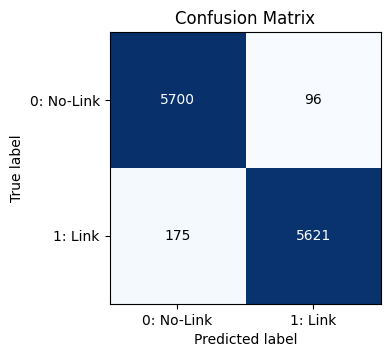

In [ ]:
# Compute CM
cm = confusion_matrix(y_test, y_pred)

# Plot with imshow (no colorbar)
fig, ax = plt.subplots(figsize=(4,4))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')

# 3. Ticks and labels: include the mapping right in the tick labels
classes = ["0: No-Link", "1: Link"]
ax.set(
    xticks=np.arange(len(classes)),
    yticks=np.arange(len(classes)),
    xticklabels=classes,
    yticklabels=classes,
    ylabel="True label",
    xlabel="Predicted label",
    title="Confusion Matrix"
)

# Annotate counts
thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "white" if cm[i, j] > thresh else "black"
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", color=color)

plt.tight_layout()
plt.show()


Anaylzing Graph 2

Nodes: 317,080  Edges: 1,049,866  Total weight: 1,049,866

Weights – Min: 1, Q1: 1, Med: 1, Q3: 1, Max: 1

Avg Deg: 6.62, Avg W-Deg: 6.62

Top nodes by degree:
 Node  Degree
38868     343
45479     296
57571     290
 6737     269
72210     264
63861     244
96321     230
13884     227
11457     225
21759     221 

Top nodes by weighted degree:
 Node  W-Degree
38868       343
45479       296
57571       290
 6737       269
72210       264
63861       244
96321       230
13884       227
11457       225
21759       221 

Components: 1, Largest: 317080 nodes (100.0%)

Avg clustering: 0.632

Top nodes by PageRank:
 Node  PageRank
57571  0.000098
 6737  0.000079
96321  0.000078
 4799  0.000070
19267  0.000069
11323  0.000067
98618  0.000066
13830  0.000065
37335  0.000064
21759  0.000063 

--- Degree Distribution data ---
 bin_left  bin_right  count
      1.0       18.1 296521
     18.1       35.2  14143
     35.2       52.3   3709
     52.3       69.4   1424
     69.4       86.5    538
    

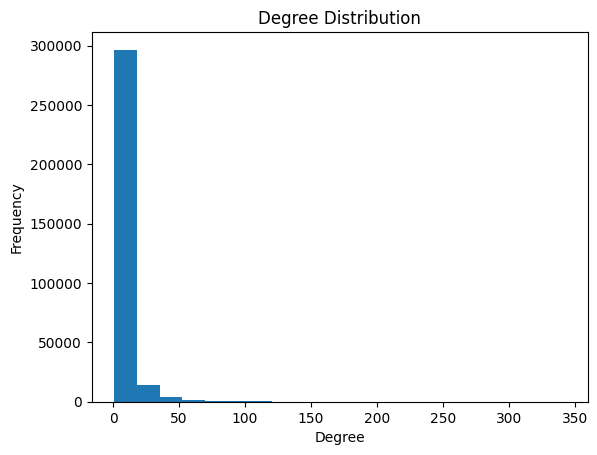

--- Weighted Degree Distribution data ---
 bin_left  bin_right  count
      1.0       18.1 296521
     18.1       35.2  14143
     35.2       52.3   3709
     52.3       69.4   1424
     69.4       86.5    538
     86.5      103.6    295
    103.6      120.7    213
    120.7      137.8    102
    137.8      154.9     57
    154.9      172.0     35
    172.0      189.1     18
    189.1      206.2      7
    206.2      223.3      9
    223.3      240.4      3
    240.4      257.5      1
    257.5      274.6      2
    274.6      291.7      1
    291.7      308.8      1
    308.8      325.9      0
    325.9      343.0      1 



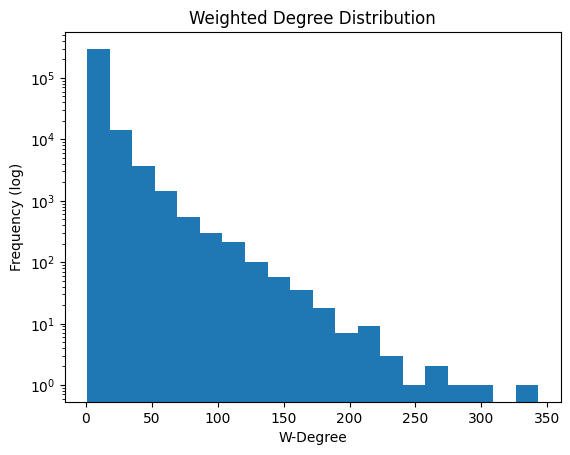

--- Component Size Distribution data ---
 bin_left  bin_right  count
317079.50  317079.55      0
317079.55  317079.60      0
317079.60  317079.65      0
317079.65  317079.70      0
317079.70  317079.75      0
317079.75  317079.80      0
317079.80  317079.85      0
317079.85  317079.90      0
317079.90  317079.95      0
317079.95  317080.00      0
317080.00  317080.05      1
317080.05  317080.10      0
317080.10  317080.15      0
317080.15  317080.20      0
317080.20  317080.25      0
317080.25  317080.30      0
317080.30  317080.35      0
317080.35  317080.40      0
317080.40  317080.45      0
317080.45  317080.50      0 



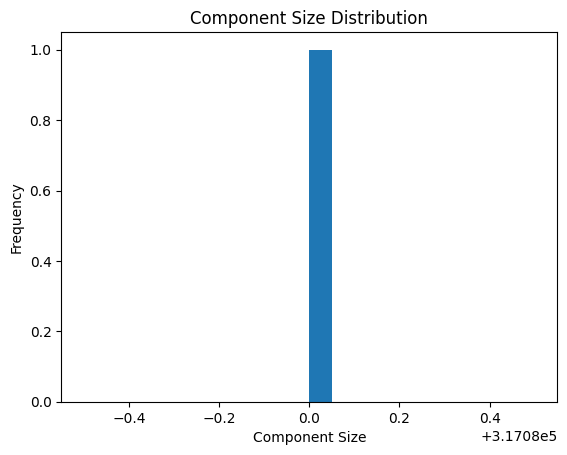

In [ ]:
metrics = summarize_graph(G2, top_n=10)


Community 1 — size 7313
  Sample authors: ['16273', '21738', '32467', '189356', '92370', '24459', '364237', '58561', '210516', '34320'] …

Community 2 — size 1180
  Sample authors: ['31753', '120343', '163478', '32501', '198074', '305551', '363493', '195044', '366152', '302174'] …

Community 3 — size 332
  Sample authors: ['63227', '189655', '408987', '291757', '116555', '74770', '65959', '241405', '178333', '307088'] …

Community 4 — size 292
  Sample authors: ['138812', '69054', '361636', '384518', '256664', '109825', '361652', '305408', '387458', '156819'] …

Community 5 — size 281
  Sample authors: ['99721', '114382', '208151', '334847', '277824', '216229', '91478', '122663', '336930', '282883'] …

Number of communities: 46351
Mean size: 6.8, median size: 4
Largest: 7313, smallest: 2
Found 46192 communities
  Largest: 8825, Smallest: 2, Median: 4


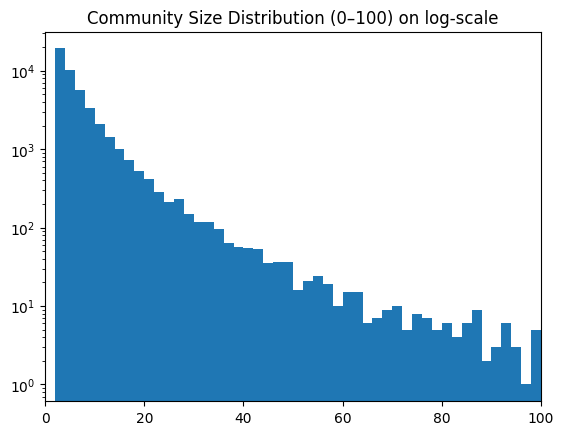

In [ ]:
# generator of sets of nodes
communities = list(asyn_lpa_communities(G2, weight="weight"))

# sort by size
communities.sort(key=len, reverse=True)

for i, comm in enumerate(communities[:5], 1):
    print(f"Community {i} — size {len(comm)}")
    print("  Sample authors:", list(comm)[:10], "…\n")

sizes = [len(c) for c in communities]
print(f"Number of communities: {len(sizes)}")
print(f"Mean size: {statistics.mean(sizes):.1f}, median size: {statistics.median(sizes)}")
print(f"Largest: {max(sizes)}, smallest: {min(sizes)}")

# Run greedy modularity to find communities
communities = list(asyn_lpa_communities(G2, weight="weight"))

# Get the size of each community
sizes = [len(c) for c in communities]

# Print basic stats
print(f"Found {len(sizes)} communities")
print(f"  Largest: {max(sizes)}, Smallest: {min(sizes)}, Median: {sorted(sizes)[len(sizes)//2]}")

plt.figure()
plt.hist(sizes, bins=50, range=(0, 100))
plt.xlim(0, 100)
plt.yscale('log')
plt.title("Community Size Distribution (0–100) on log-scale")
plt.show()


# Build a map: node → community ID
community_map = {}
for cid, comm in enumerate(communities):
    for n in comm:
        community_map[n] = cid

# Precompute neighbor sets for speed
nbrs = {n: set(G2.neighbors(n)) for n in G2.nodes()}

In [ ]:
# ------------ Generate candidate pairs ---------------------------
# (Here: all existing edges as positives; sample equal # of non‐edges for negatives)
positive_pairs = list(G2.edges())
all_nodes = list(G2.nodes())
# simple negative sampling (randomly pick non‐edges)
import random
neg_samples = set()
while len(neg_samples) < len(positive_pairs):
    u, v = random.sample(all_nodes, 2)
    if not G2.has_edge(u, v):
        neg_samples.add((u, v))
negative_pairs = list(neg_samples)

In [ ]:
# Label them
data2 = []
for u, v, label in [(u, v, 1) for u,v in positive_pairs] + [(u, v, 0) for u,v in negative_pairs]:
    Nu, Nv = nbrs.get(u, set()), nbrs.get(v, set())
    cn = len(Nu & Nv)
    union = Nu | Nv
    # Get Jacard Coefficient
    jaccard = cn/len(union) if union else 0.0

    # Adamic–Adar Index
    aa = 0.0

    # Only compute if there’s at least one common neighbor
    if cn > 0:
        # Get the set of common neighbors
        common_neighbors = Nu & Nv

        # Sum 1/log(degree) for each common neighbor
        for w in common_neighbors:
          # How many neighbors does w have?
          degree_w = len(nbrs[w])
          # Accumulate the Adamic–Adar contribution
          contribution = 1 / math.log(degree_w + 1)
          aa += contribution
    # If cn == 0, aa remains 0.0


    # Preferential attachment
    pa = len(Nu) * len(Nv)
    # Same community?
    same_comm = int(community_map.get(u, -1) == community_map.get(v, -1))

    data2.append({
        'u': u, 'v': v, 'label': label,
        'common_neighbors': cn,
        'jaccard': jaccard,
        'adamic_adar': aa,
        'pref_attachment': pa,
        'same_community': same_comm
    })

# Build a DataFrame
features_df2 = pd.DataFrame(data2)
print(features_df2.head())

   u      v  label  common_neighbors   jaccard  adamic_adar  pref_attachment  \
0  0      1      1                 1  0.009434     0.303413             1456   
1  0      2      1                 3  0.076923     0.810874              416   
2  0   4519      1                 2  0.040816     0.744962              560   
3  0  23073      1                 1  0.022222     0.417032              480   
4  0  33043      1                 2  0.040816     0.540408              560   

   same_community  
0               1  
1               1  
2               1  
3               1  
4               1  


In [ ]:
# Split features and labels
X2 = features_df2.drop(['u','v','label'], axis=1)

y2 = features_df2['label']

# Train/test split
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

# Train model
model = GaussianNB()
model.fit(X_train2, y_train2)
y_pred2 = model.predict(X_test2)




=== Classification Report ===
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    209992
           1       1.00      0.98      0.99    209955

    accuracy                           0.99    419947
   macro avg       0.99      0.99      0.99    419947
weighted avg       0.99      0.99      0.99    419947


=== Scalar Metrics ===
accuracy            : 0.9868
precision           : 0.9954
recall              : 0.9782
specificity         : 0.9955
f1_score            : 0.9867
balanced_accuracy   : 0.9868
mcc                 : 0.9738
cohen_kappa         : 0.9737
youden_j            : 0.9737
roc_auc             : 0.9914
pr_auc              : 0.9933
log_loss            : 0.2305
brier_score         : 0.0130

Precision@100: 1.0000
NDCG@100:        0.9977

=== Calibration Curve (10 bins) ===
   pred_bin  true_frac
0  0.000044   0.021319
1  0.151510   0.206897
2  0.244639   0.354839
3  0.346411   0.333333
4  0.444008   0.352941
5  0.533365   0.4615

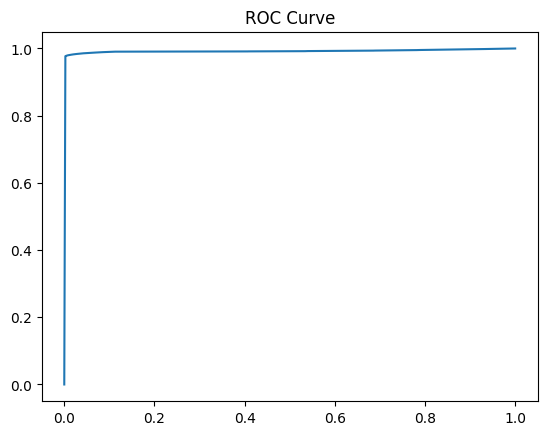

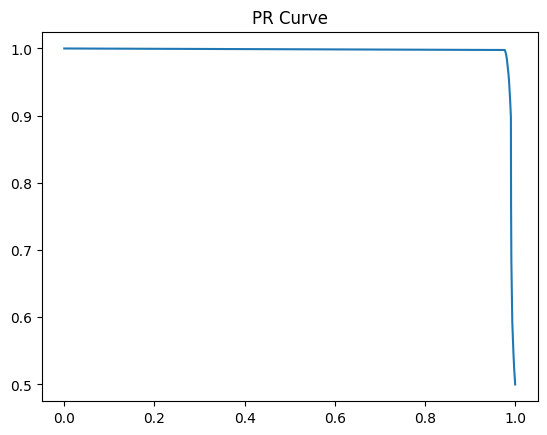

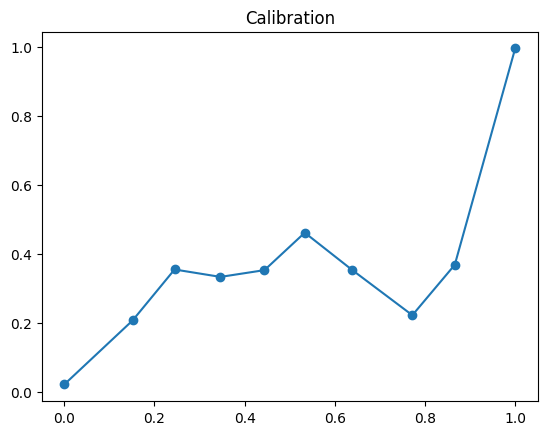

In [ ]:
# Get predicted probabilities for the positive class
y_proba2 = model.predict_proba(X_test2)[:, 1]

# Basic confusion-matrix metrics
tn, fp, fn, tp = confusion_matrix(y_test2, y_pred2).ravel()
metrics = {
    "accuracy":           accuracy_score(y_test2, y_pred2),
    "precision":          precision_score(y_test2, y_pred2),
    "recall":             recall_score(y_test2, y_pred2),
    "specificity":        tn / (tn + fp) if (tn + fp)>0 else np.nan,
    "f1_score":           f1_score(y_test2, y_pred2),
    "balanced_accuracy":  balanced_accuracy_score(y_test2, y_pred2),
    "mcc":                matthews_corrcoef(y_test2, y_pred2),
    "cohen_kappa":        cohen_kappa_score(y_test2, y_pred2),
    "youden_j":           recall_score(y_test2, y_pred2) + (tn/(tn+fp)) - 1,
}

# Threshold‐independent / ranking metrics
metrics.update({
    "roc_auc":            roc_auc_score(y_test2, y_proba2),
    "pr_auc":             average_precision_score(y_test2, y_proba2),
})

# Probabilistic / calibration metrics
metrics.update({
    "log_loss":           log_loss(y_test2, y_proba2),
    "brier_score":        brier_score_loss(y_test2, y_proba2),
})

# Display a nice classification report
print("=== Classification Report ===")
print(classification_report(y_test2, y_pred2))

# Print the scalar metrics
print("\n=== Scalar Metrics ===")
for k, v in metrics.items():
    print(f"{k:20s}: {v:.4f}")

# Precision-Recall & ROC curves (arrays you can plot)
precisions, recalls, pr_thresholds = precision_recall_curve(y_test2, y_proba2)
fprs, tprs, roc_thresholds       = roc_curve(y_test2, y_proba2)

# Precision@k  (e.g. top 100 predictions)
k = 100
sorted_idx = np.argsort(y_proba2)[::-1]
topk      = sorted_idx[:k]
precision_at_k = y_test2.iloc[topk].mean()
print(f"\nPrecision@{k}: {precision_at_k:.4f}")

# NDCG@k (requires a 2D array, here we treat positive=1, negative=0 as relevance)
#    For a single sample, wrap into a list
ndcg_at_k = ndcg_score([y_test2.values], [y_proba2], k=k)
print(f"NDCG@{k}:        {ndcg_at_k:.4f}")

# Calibration curve
prob_true, prob_pred = calibration_curve(y_test2, y_proba2, n_bins=10)
calib_df = pd.DataFrame({
    "pred_bin": prob_pred,
    "true_frac": prob_true
})
print("\n=== Calibration Curve (10 bins) ===")
print(calib_df)

plt.plot(fprs, tprs); plt.title("ROC Curve"); plt.show()
plt.plot(recalls, precisions); plt.title("PR Curve"); plt.show()
plt.plot(prob_pred, prob_true, marker='o'); plt.title("Calibration"); plt.show()
